In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
# 1. Load Data
df = pd.read_csv("Daily_Water_Intake.csv")

In [3]:
# 2. Encode Categorical Columns
label_encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = label_encoder.fit_transform(df[col].astype(str))


In [4]:
# 3. Define Features and Target

X = df.drop("Hydration Level", axis=1)

y = df["Hydration Level"]

In [5]:
# 4. Split Data

X = df.drop('Hydration Level', axis=1)

y = df['Hydration Level']


# Train-Test Splitting

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)


# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [6]:
# TRAINING MODEL: Logistic Regression

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)


# MODEL EVALUATION

print("--- Logistic Regression Evaluation ---")

print("Accuracy:", accuracy_score(y_test, lr_preds))

print("Confusion Matrix:\n", confusion_matrix(y_test, lr_preds))

print("Classification Report:\n", classification_report(y_test, lr_preds))

--- Logistic Regression Evaluation ---
Accuracy: 0.9976666666666667
Confusion Matrix:
 [[4788    0]
 [  14 1198]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4788
           1       1.00      0.99      0.99      1212

    accuracy                           1.00      6000
   macro avg       1.00      0.99      1.00      6000
weighted avg       1.00      1.00      1.00      6000



In [7]:
# TRAINING MODEL: Random Forest

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)


# MODEL EVALUATION

print("\n--- Random Forest Evaluation ---")

print("Accuracy:", accuracy_score(y_test, rf_preds))

print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))

print("Classification Report:\n", classification_report(y_test, rf_preds))


--- Random Forest Evaluation ---
Accuracy: 0.9915
Confusion Matrix:
 [[4776   12]
 [  39 1173]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      4788
           1       0.99      0.97      0.98      1212

    accuracy                           0.99      6000
   macro avg       0.99      0.98      0.99      6000
weighted avg       0.99      0.99      0.99      6000



In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# TRAINING LOGISTIC REGRESSION

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_scaled, y_train)


# TRAINING RANDOM FOREST

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)


# CHECKING MODEL PARAMETERS

print("Logistic Regression Intercept:")

print(lr_model.intercept_)


print("\nLogistic Regression Coefficients:")

print(lr_model.coef_)


print("\nRandom Forest Feature Importances:")

print(rf_model.feature_importances_)

Logistic Regression Intercept:
[-15.15240009]

Logistic Regression Coefficients:
[[ 7.13351925e-02  1.77287219e-02  1.53726122e+01 -2.26774546e+01
  -6.22587834e-02 -9.27805681e-02]]

Random Forest Feature Importances:
[0.04918901 0.00348607 0.33608096 0.36021044 0.14397759 0.10705593]


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize and Train the models

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_scaled, y_train)


# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)


# 2. GENERATE PREDICTIONS

y_pred_lr = lr_model.predict(X_test_scaled)

y_pred_rf = rf_model.predict(X_test)


# 3. EVALUATION METRICS

# Logistic Regression
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report (LR):")

print(classification_report(y_test, y_pred_lr))


print("-" * 40)


# Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report (RF):")

print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.9976666666666667

Classification Report (LR):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4788
           1       1.00      0.99      0.99      1212

    accuracy                           1.00      6000
   macro avg       1.00      0.99      1.00      6000
weighted avg       1.00      1.00      1.00      6000

----------------------------------------
Random Forest Accuracy: 0.9915

Classification Report (RF):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4788
           1       0.99      0.97      0.98      1212

    accuracy                           0.99      6000
   macro avg       0.99      0.98      0.99      6000
weighted avg       0.99      0.99      0.99      6000



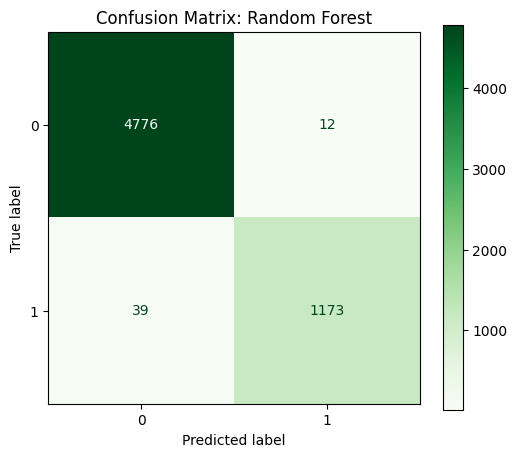

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Generate the plot
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap='Greens',
    ax=ax
)

ax.set_title("Confusion Matrix: Random Forest")

plt.show()

In [11]:
# CHECKING ACCURACY

print("--- Random Forest ---")

print("Training Accuracy:", rf_model.score(X_train, y_train))

print("Test Accuracy:", rf_model.score(X_test, y_test))

--- Random Forest ---
Training Accuracy: 1.0
Test Accuracy: 0.9915


In [12]:
import pickle

# Save Random Forest Model

with open("model.pkl", "wb") as file:
    
    pickle.dump(rf_model, file)


# Save Scaler

with open("scaler.pkl", "wb") as file:
    
    pickle.dump(scaler, file)


print("Model and scaler saved successfully")

Model and scaler saved successfully
